In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic-machine-learning-from-disaster/train.csv
/kaggle/input/titanic-machine-learning-from-disaster/test.csv


In [27]:
import pandas as pd

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')
test_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/test.csv')

print(train_data.head())
print(test_data.head())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
  

In [28]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
print(train_data.columns)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [30]:
# Eliminar una columna del DataFrame
train_data = train_data.drop('Cabin', axis=1)


In [31]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [32]:
# Calcular la media de la columna Age, ignorando valores faltantes
mean_age = train_data['Age'].mean()

# Imputar los valores faltantes en la columna Age con la media
train_data['Age'] = train_data['Age'].fillna(mean_age)

# Resultado: lleno los datos faltantes con la media
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [33]:
train_data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [34]:
# Eliminar una columna del DataFrame
ytrain = train_data['Survived']
train_data = train_data.drop(['Name','Survived'], axis=1)
train_data = train_data.drop('Ticket', axis=1)
train_data = train_data.drop('PassengerId', axis=1)
# Mostrar resultado
train_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


In [35]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
encoder_ = OrdinalEncoder()
lista = ["Sex","Embarked"]
train_data[lista] = encoder_.fit_transform(train_data[lista])
imputer_ = SimpleImputer(strategy='most_frequent')
train_data[['Age','Embarked']] = imputer_.fit_transform(train_data[['Age','Embarked']])

In [36]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    float64
 2   Age       891 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  891 non-null    float64
dtypes: float64(4), int64(3)
memory usage: 48.9 KB


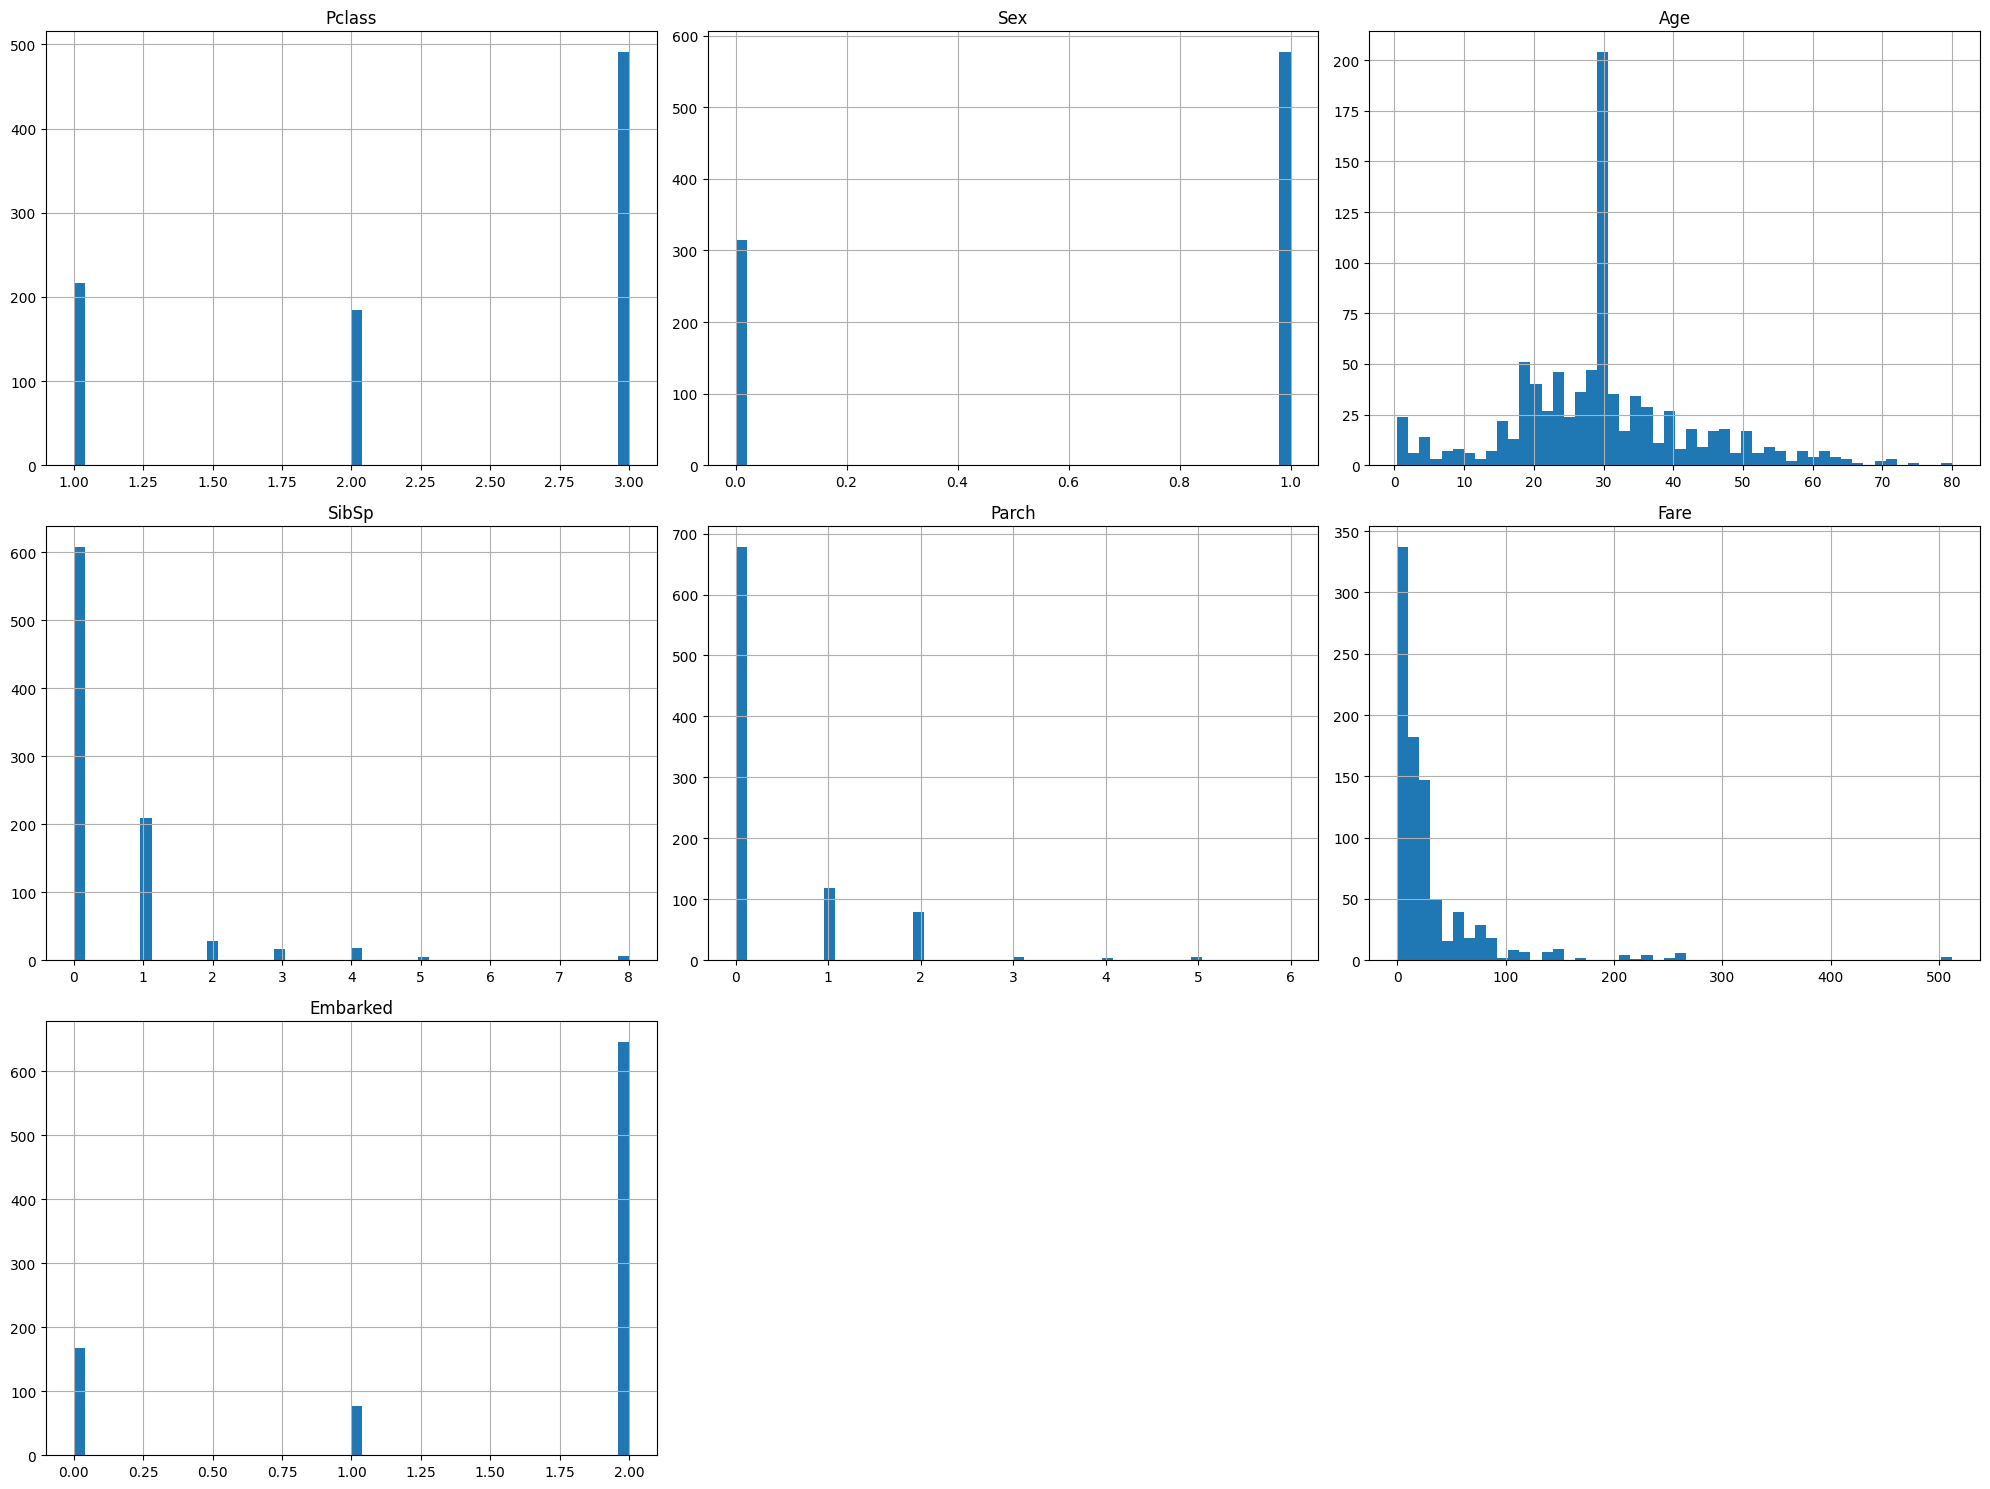

In [37]:
import matplotlib.pyplot as plt

train_data.hist(bins=50, figsize=(20,15))
plt.tight_layout()
plt.show()

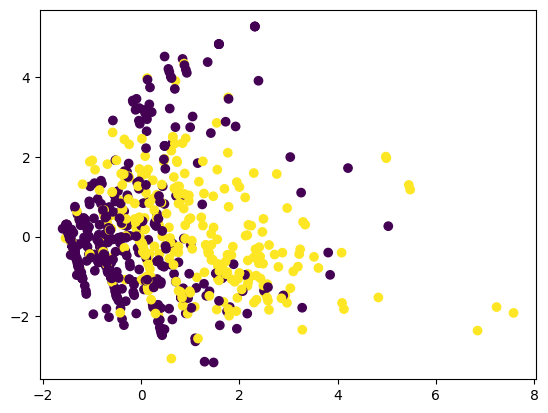

In [38]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
sca_ = StandardScaler()
red_ = PCA(n_components = 2)
ztrain = red_.fit_transform(sca_.fit_transform(train_data))
ztrain.shape
plt.scatter(ztrain[:,0],ztrain[:,1],c=ytrain)

✅ Accuracy del modelo: 0.791

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.82      0.83       165
   Sobrevivió       0.72      0.74      0.73       103

     accuracy                           0.79       268
    macro avg       0.78      0.78      0.78       268
 weighted avg       0.79      0.79      0.79       268



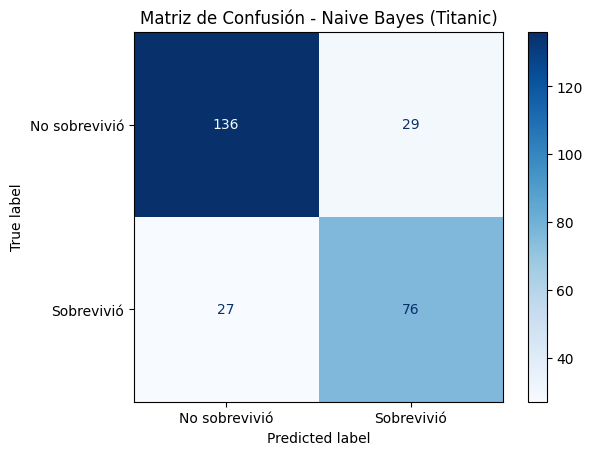

In [39]:
# ======================================================
# 🧠 Clasificador Naive Bayes - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (importante para NB)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo Naive Bayes
# ------------------------------------------------------
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = nb_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Naive Bayes (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.791

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.82      0.85      0.83       165
   Sobrevivió       0.75      0.69      0.72       103

     accuracy                           0.79       268
    macro avg       0.78      0.77      0.78       268
 weighted avg       0.79      0.79      0.79       268



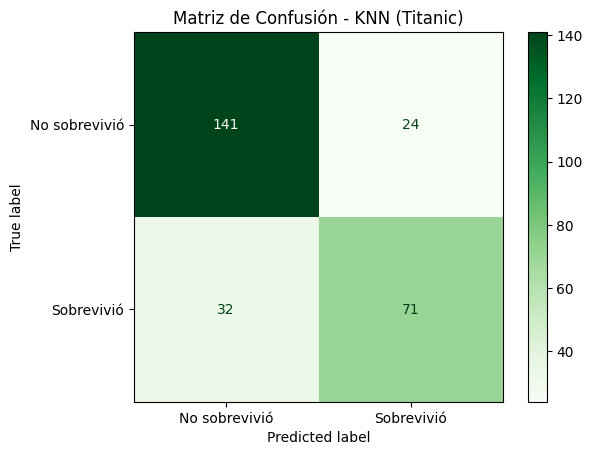

In [40]:
# ======================================================
# 🤖 Clasificador KNN - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (KNN depende de distancias)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo KNN
# ------------------------------------------------------
# k=5 suele ser un buen punto de partida
knn_model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = knn_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Greens")
plt.title("Matriz de Confusión - KNN (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.7985

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.85      0.84       165
   Sobrevivió       0.75      0.72      0.73       103

     accuracy                           0.80       268
    macro avg       0.79      0.78      0.79       268
 weighted avg       0.80      0.80      0.80       268



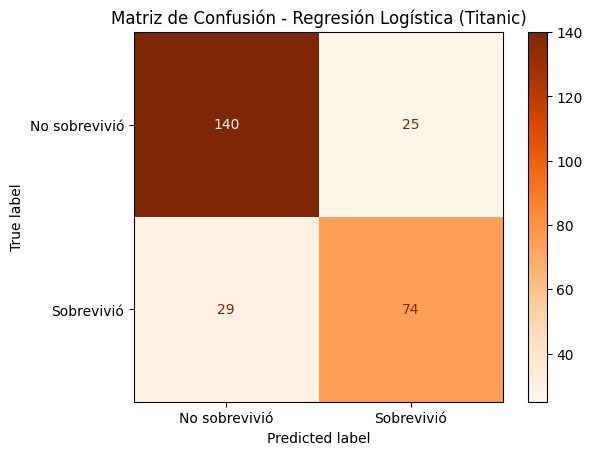

In [41]:
# ======================================================
# 📈 Clasificador Regresión Logística - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo de Regresión Logística
# ------------------------------------------------------
log_model = LogisticRegression(max_iter=1000, solver='lbfgs')
log_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = log_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Oranges")
plt.title("Matriz de Confusión - Regresión Logística (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.7985

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.81      0.88      0.84       165
   Sobrevivió       0.78      0.66      0.72       103

     accuracy                           0.80       268
    macro avg       0.79      0.77      0.78       268
 weighted avg       0.80      0.80      0.79       268



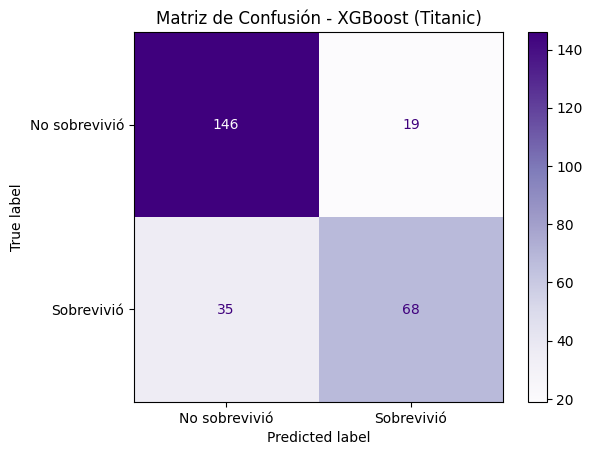

In [42]:
# ======================================================
# 🚀 Clasificador XGBoost - Titanic
# ======================================================

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (opcional pero recomendable)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo XGBoost
# ------------------------------------------------------
xgb_model = XGBClassifier(
    n_estimators=200,        # número de árboles
    learning_rate=0.05,      # tasa de aprendizaje
    max_depth=4,             # profundidad máxima de los árboles
    subsample=0.8,           # porcentaje de muestras por árbol
    colsample_bytree=0.8,    # porcentaje de variables por árbol
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'    # métrica para evitar warnings
)
xgb_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = xgb_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - XGBoost (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.7985

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.79      0.92      0.85       165
   Sobrevivió       0.82      0.61      0.70       103

     accuracy                           0.80       268
    macro avg       0.80      0.76      0.77       268
 weighted avg       0.80      0.80      0.79       268



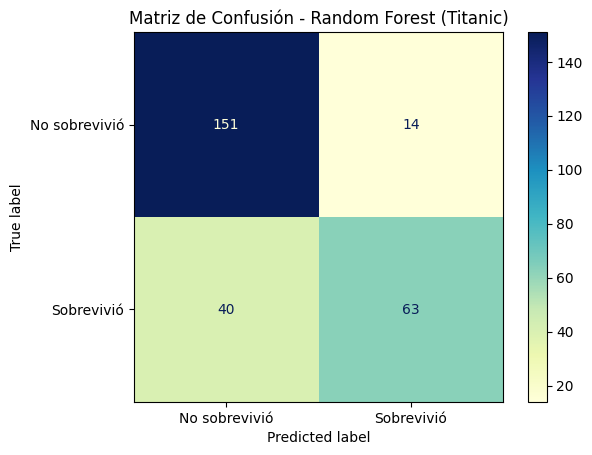

In [43]:
# ======================================================
# 🌲 Clasificador Random Forest - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (opcional en árboles, pero mantiene coherencia)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo Random Forest
# ------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=200,     # número de árboles
    max_depth=6,          # profundidad máxima de cada árbol
    min_samples_split=4,  # división mínima para crear ramas
    min_samples_leaf=2,   # tamaño mínimo de las hojas
    random_state=42,
    n_jobs=-1             # usa todos los núcleos del CPU
)
rf_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = rf_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="YlGnBu")
plt.title("Matriz de Confusión - Random Forest (Titanic)")
plt.show()


✅ Accuracy del modelo: 0.8022

📋 Reporte de Clasificación:
               precision    recall  f1-score   support

No sobrevivió       0.81      0.88      0.85       165
   Sobrevivió       0.78      0.68      0.73       103

     accuracy                           0.80       268
    macro avg       0.80      0.78      0.79       268
 weighted avg       0.80      0.80      0.80       268



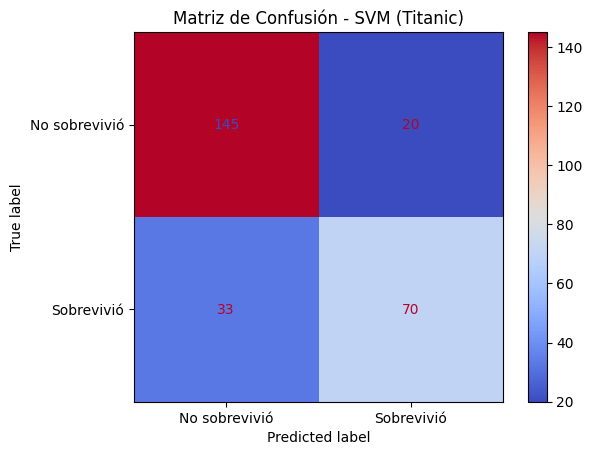

In [44]:
# ======================================================
# ⚙️ Clasificador SVM (Support Vector Machine) - Titanic
# ======================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------
# 1️⃣ División de los datos (70% entrenamiento, 30% prueba)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# ------------------------------------------------------
# 2️⃣ Escalado de características (SVM depende de distancias)
# ------------------------------------------------------
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 3️⃣ Entrenamiento del modelo SVM
# ------------------------------------------------------
svm_model = SVC(
    kernel='rbf',         # 'rbf' = radial basis function, ideal para relaciones no lineales
    C=1.0,                # controla la penalización por errores
    gamma='scale',        # define la influencia de cada punto
    probability=True,     # permite calcular probabilidades posteriores
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

# ------------------------------------------------------
# 4️⃣ Predicciones
# ------------------------------------------------------
y_pred = svm_model.predict(X_test_scaled)

# ------------------------------------------------------
# 5️⃣ Evaluación del modelo
# ------------------------------------------------------
print("✅ Accuracy del modelo:", round(accuracy_score(y_test, y_pred), 4))
print("\n📋 Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))

# ------------------------------------------------------
# 6️⃣ Matriz de confusión
# ------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap="coolwarm")
plt.title("Matriz de Confusión - SVM (Titanic)")
plt.show()


In [45]:
!python -c "import cudf, cuml; print('✅ RAPIDS está disponible y listo para usar')"

✅ RAPIDS está disponible y listo para usar


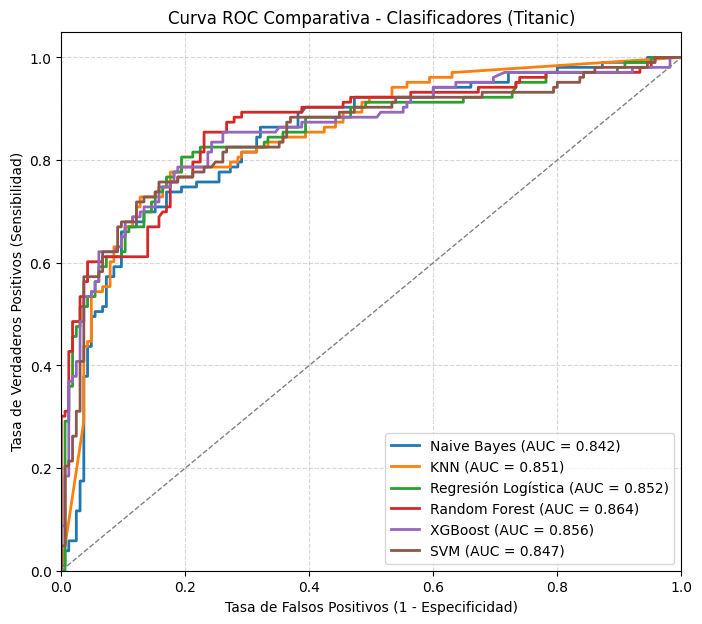

In [46]:
# ======================================================
# 🎯 Curvas ROC - Comparación de Clasificadores (Titanic)
# ======================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ------------------------------------------------------
# 1️⃣ División del dataset
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    train_data, ytrain, test_size=0.3, random_state=42, stratify=ytrain
)

# Escalar (necesario para KNN, SVM, Regresión Logística)
sca_ = StandardScaler()
X_train_scaled = sca_.fit_transform(X_train)
X_test_scaled = sca_.transform(X_test)

# ------------------------------------------------------
# 2️⃣ Inicializar clasificadores
# ------------------------------------------------------
models = {
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=7, weights='distance'),
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                              n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)
}

# ------------------------------------------------------
# 3️⃣ Calcular curvas ROC y AUC
# ------------------------------------------------------
plt.figure(figsize=(8, 7))
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    # Probabilidad de pertenecer a la clase positiva
    y_score = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

# ------------------------------------------------------
# 4️⃣ Gráfico general
# ------------------------------------------------------
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de Falsos Positivos (1 - Especificidad)")
plt.ylabel("Tasa de Verdaderos Positivos (Sensibilidad)")
plt.title("Curva ROC Comparativa - Clasificadores (Titanic)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Busqueda de hiperparametros con grid search y opt bayesiana de los clasificadores

# Naive Bayes

🔹 Iniciando Grid Search...
✅ Mejor parámetro (Grid Search): {'var_smoothing': 1e-12}
✅ Mejor accuracy (Grid Search): 0.7908
⏱️ Tiempo total Grid Search: 0.10 segundos

🔹 Iniciando Optimización Bayesiana...
✅ Mejor parámetro (BayesSearch): OrderedDict([('var_smoothing', 2.888176653914472e-10)])
✅ Mejor accuracy (BayesSearch): 0.7908
⏱️ Tiempo total BayesSearch: 4.71 segundos



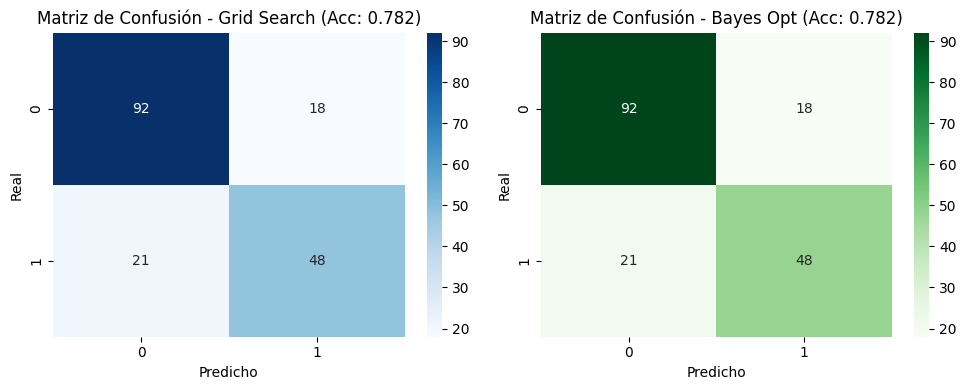

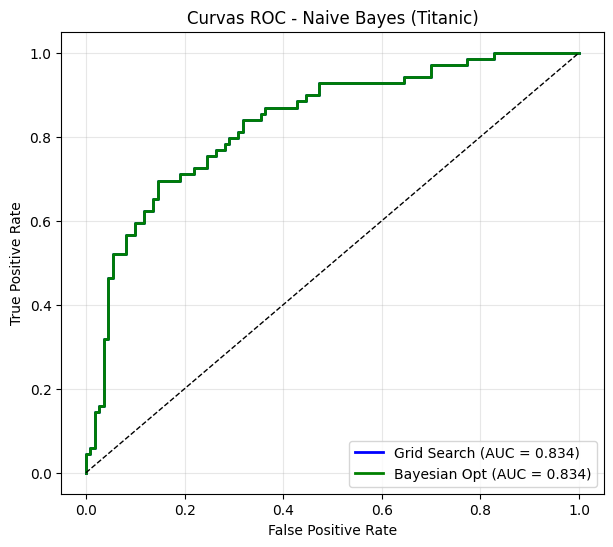

📊 Comparación Final:
Grid Search  -> Accuracy: 0.7821 | AUC: 0.8337 | Tiempo: 0.10s
Bayes Opt    -> Accuracy: 0.7821 | AUC: 0.8337 | Tiempo: 4.71s

📘 Reporte Clasificación (Bayesian Opt):
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       110
           1       0.73      0.70      0.71        69

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [48]:
# ============================================================
# 🔎 Comparación de búsqueda de hiperparámetros:
#   Naive Bayes - Grid Search vs Optimización Bayesiana
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)
from skopt import BayesSearchCV

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

# Limpieza básica
train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# Codificación de variables categóricas
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

# Variables predictoras y objetivo
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ============================================================
# 2️⃣ GRID SEARCH
# ============================================================
print("🔹 Iniciando Grid Search...")
start_time = time.time()

param_grid = {'var_smoothing': np.logspace(-12, -6, 10)}

grid_search = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro (Grid Search): {grid_search.best_params_}")
print(f"✅ Mejor accuracy (Grid Search): {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ OPTIMIZACIÓN BAYESIANA
# ============================================================
print("🔹 Iniciando Optimización Bayesiana...")
start_time = time.time()

search_spaces = {'var_smoothing': (1e-12, 1e-6, 'log-uniform')}
bayes_search = BayesSearchCV(
    estimator=GaussianNB(),
    search_spaces=search_spaces,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
bayes_search.fit(X_train, y_train)
bayes_time = time.time() - start_time

print(f"✅ Mejor parámetro (BayesSearch): {bayes_search.best_params_}")
print(f"✅ Mejor accuracy (BayesSearch): {bayes_search.best_score_:.4f}")
print(f"⏱️ Tiempo total BayesSearch: {bayes_time:.2f} segundos\n")

# ============================================================
# 4️⃣ EVALUACIÓN FINAL EN TEST
# ============================================================

# Modelos finales
best_grid_model = grid_search.best_estimator_
best_bayes_model = bayes_search.best_estimator_

# Predicciones
y_pred_grid = best_grid_model.predict(X_test)
y_pred_bayes = best_bayes_model.predict(X_test)

# Accuracy
acc_grid = accuracy_score(y_test, y_pred_grid)
acc_bayes = accuracy_score(y_test, y_pred_bayes)

# ============================================================
# 5️⃣ MATRICES DE CONFUSIÓN
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f"Matriz de Confusión - Grid Search (Acc: {acc_grid:.3f})")
ax[0].set_xlabel("Predicho")
ax[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_bayes), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title(f"Matriz de Confusión - Bayes Opt (Acc: {acc_bayes:.3f})")
ax[1].set_xlabel("Predicho")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

# ============================================================
# 6️⃣ CURVAS ROC Y AUC
# ============================================================

# Probabilidades para ROC
y_prob_grid = best_grid_model.predict_proba(X_test)[:,1]
y_prob_bayes = best_bayes_model.predict_proba(X_test)[:,1]

fpr_g, tpr_g, _ = roc_curve(y_test, y_prob_grid)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_bayes)
roc_auc_g = auc(fpr_g, tpr_g)
roc_auc_b = auc(fpr_b, tpr_b)

plt.figure(figsize=(7,6))
plt.plot(fpr_g, tpr_g, color='blue', lw=2, label=f'Grid Search (AUC = {roc_auc_g:.3f})')
plt.plot(fpr_b, tpr_b, color='green', lw=2, label=f'Bayesian Opt (AUC = {roc_auc_b:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - Naive Bayes (Titanic)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 7️⃣ RESULTADOS FINALES
# ============================================================

print("📊 Comparación Final:")
print(f"Grid Search  -> Accuracy: {acc_grid:.4f} | AUC: {roc_auc_g:.4f} | Tiempo: {grid_time:.2f}s")
print(f"Bayes Opt    -> Accuracy: {acc_bayes:.4f} | AUC: {roc_auc_b:.4f} | Tiempo: {bayes_time:.2f}s\n")

print("📘 Reporte Clasificación (Bayesian Opt):")
print(classification_report(y_test, y_pred_bayes))


# KNN

🔹 Iniciando Grid Search para KNN...
✅ Mejor parámetro (Grid Search): {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
✅ Mejor accuracy (Grid Search): 0.7628
⏱️ Tiempo total Grid Search: 0.60 segundos

🔹 Iniciando Optimización Bayesiana para KNN...
✅ Mejor parámetro (BayesSearch): OrderedDict([('metric', 'manhattan'), ('n_neighbors', 10), ('weights', 'distance')])
✅ Mejor accuracy (BayesSearch): 0.7684
⏱️ Tiempo total BayesSearch: 20.70 segundos



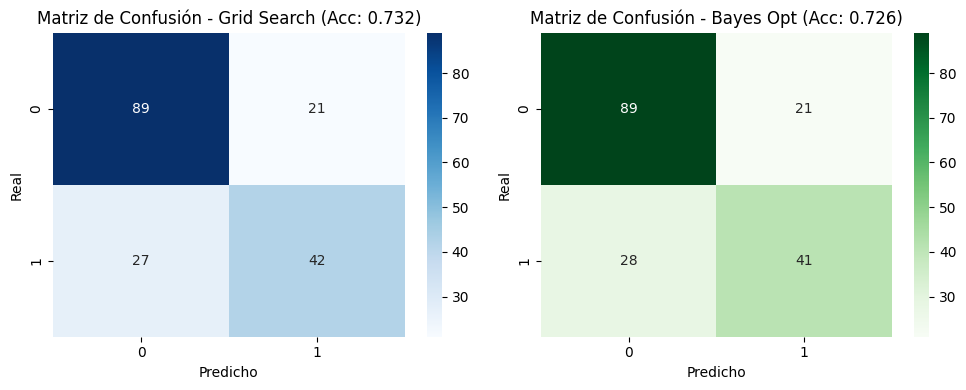

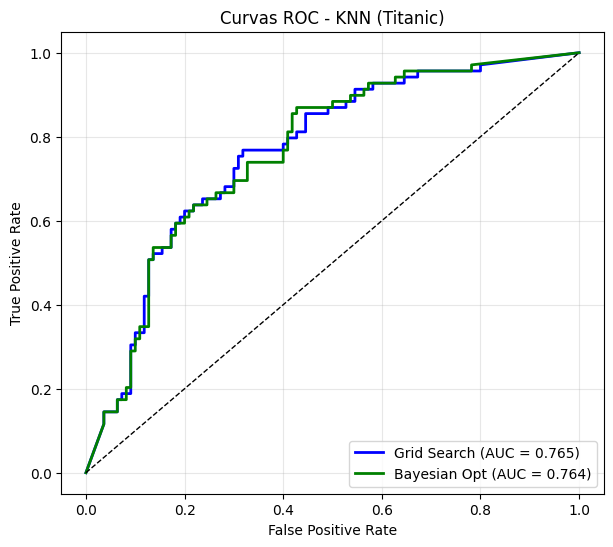

📊 Comparación Final:
Grid Search  -> Accuracy: 0.7318 | AUC: 0.7648 | Tiempo: 0.60s
Bayes Opt    -> Accuracy: 0.7263 | AUC: 0.7639 | Tiempo: 20.70s

📘 Reporte Clasificación (Bayesian Opt):
              precision    recall  f1-score   support

           0       0.76      0.81      0.78       110
           1       0.66      0.59      0.63        69

    accuracy                           0.73       179
   macro avg       0.71      0.70      0.71       179
weighted avg       0.72      0.73      0.72       179



In [49]:
# ============================================================
# 🔎 Comparación de búsqueda de hiperparámetros:
#   KNN - Grid Search vs Optimización Bayesiana
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from skopt import BayesSearchCV

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

# Limpieza básica
train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# Codificación de variables categóricas
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

# Variables predictoras y objetivo
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ============================================================
# 2️⃣ GRID SEARCH
# ============================================================
print("🔹 Iniciando Grid Search para KNN...")
start_time = time.time()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro (Grid Search): {grid_search.best_params_}")
print(f"✅ Mejor accuracy (Grid Search): {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ OPTIMIZACIÓN BAYESIANA
# ============================================================
print("🔹 Iniciando Optimización Bayesiana para KNN...")
start_time = time.time()

search_spaces = {
    'n_neighbors': (3, 15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

bayes_search = BayesSearchCV(
    estimator=KNeighborsClassifier(),
    search_spaces=search_spaces,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
bayes_search.fit(X_train, y_train)
bayes_time = time.time() - start_time

print(f"✅ Mejor parámetro (BayesSearch): {bayes_search.best_params_}")
print(f"✅ Mejor accuracy (BayesSearch): {bayes_search.best_score_:.4f}")
print(f"⏱️ Tiempo total BayesSearch: {bayes_time:.2f} segundos\n")

# ============================================================
# 4️⃣ EVALUACIÓN FINAL EN TEST
# ============================================================

# Modelos finales
best_grid_model = grid_search.best_estimator_
best_bayes_model = bayes_search.best_estimator_

# Predicciones
y_pred_grid = best_grid_model.predict(X_test)
y_pred_bayes = best_bayes_model.predict(X_test)

# Accuracy
acc_grid = accuracy_score(y_test, y_pred_grid)
acc_bayes = accuracy_score(y_test, y_pred_bayes)

# ============================================================
# 5️⃣ MATRICES DE CONFUSIÓN
# ============================================================

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title(f"Matriz de Confusión - Grid Search (Acc: {acc_grid:.3f})")
ax[0].set_xlabel("Predicho")
ax[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_bayes), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title(f"Matriz de Confusión - Bayes Opt (Acc: {acc_bayes:.3f})")
ax[1].set_xlabel("Predicho")
ax[1].set_ylabel("Real")

plt.tight_layout()
plt.show()

# ============================================================
# 6️⃣ CURVAS ROC Y AUC
# ============================================================

# Probabilidades para ROC (usando predict_proba)
y_prob_grid = best_grid_model.predict_proba(X_test)[:,1]
y_prob_bayes = best_bayes_model.predict_proba(X_test)[:,1]

fpr_g, tpr_g, _ = roc_curve(y_test, y_prob_grid)
fpr_b, tpr_b, _ = roc_curve(y_test, y_prob_bayes)
roc_auc_g = auc(fpr_g, tpr_g)
roc_auc_b = auc(fpr_b, tpr_b)

plt.figure(figsize=(7,6))
plt.plot(fpr_g, tpr_g, color='blue', lw=2, label=f'Grid Search (AUC = {roc_auc_g:.3f})')
plt.plot(fpr_b, tpr_b, color='green', lw=2, label=f'Bayesian Opt (AUC = {roc_auc_b:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC - KNN (Titanic)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# 7️⃣ RESULTADOS FINALES
# ============================================================

print("📊 Comparación Final:")
print(f"Grid Search  -> Accuracy: {acc_grid:.4f} | AUC: {roc_auc_g:.4f} | Tiempo: {grid_time:.2f}s")
print(f"Bayes Opt    -> Accuracy: {acc_bayes:.4f} | AUC: {roc_auc_b:.4f} | Tiempo: {bayes_time:.2f}s\n")

print("📘 Reporte Clasificación (Bayesian Opt):")
print(classification_report(y_test, y_pred_bayes))


# Regresión Logistica

🔹 Iniciando Grid Search para Regresión Logística...

✅ Mejor parámetro encontrado: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'elasticnet', 'solver': 'saga'}
✅ Mejor accuracy CV: 0.8034
⏱️ Tiempo total Grid Search: 0.19 segundos



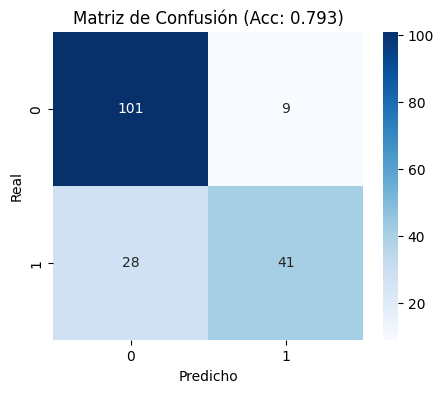

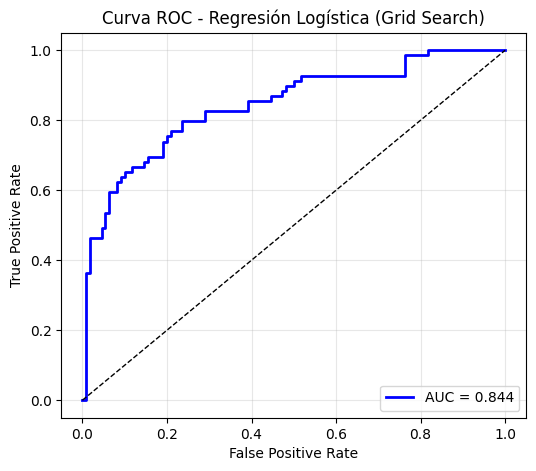

📊 Accuracy final: 0.7933 | AUC: 0.8443

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



In [52]:
# ============================================================
# 🔎 Regresión Logística con Grid Search (versión sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")  # silencia todas las advertencias

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

# Limpieza básica
train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# Codificación de variables categóricas
encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

# Separar variables
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Grid Search (solo combinaciones válidas)
# ============================================================

print("🔹 Iniciando Grid Search para Regresión Logística...\n")

start_time = time.time()

# Configuraciones válidas según el solver
param_grid = [
    # l1 con liblinear
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    # l2 con liblinear
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    # elasticnet con saga
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0, 0.5, 1]
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro encontrado: {grid_search.best_params_}")
print(f"✅ Mejor accuracy CV: {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística (Grid Search)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


🔹 Iniciando Grid Search para Regresión Logística...

✅ Mejor parámetro encontrado: {'C': 0.01, 'l1_ratio': 0, 'penalty': 'elasticnet', 'solver': 'saga'}
✅ Mejor accuracy CV: 0.8034
⏱️ Tiempo total Grid Search: 0.20 segundos



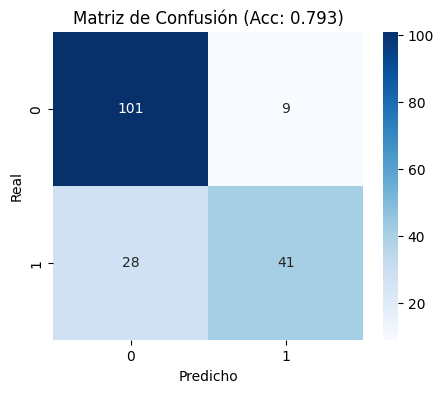

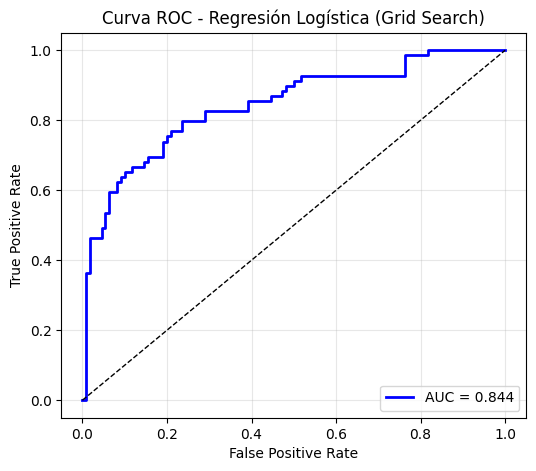

📊 Accuracy final: 0.7933 | AUC: 0.8443

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85       110
           1       0.82      0.59      0.69        69

    accuracy                           0.79       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.79      0.79       179



In [53]:
# ============================================================
# 🔎 Regresión Logística con Grid Search (versión sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")  # silencia todas las advertencias

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

# Limpieza básica
train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# Codificación de variables categóricas
encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

# Separar variables
X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Grid Search (solo combinaciones válidas)
# ============================================================

print("🔹 Iniciando Grid Search para Regresión Logística...\n")

start_time = time.time()

# Configuraciones válidas según el solver
param_grid = [
    # l1 con liblinear
    {
        'penalty': ['l1'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    # l2 con liblinear
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear']
    },
    # elasticnet con saga
    {
        'penalty': ['elasticnet'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'l1_ratio': [0, 0.5, 1]
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro encontrado: {grid_search.best_params_}")
print(f"✅ Mejor accuracy CV: {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística (Grid Search)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


# XGBoost

🔹 Iniciando Grid Search para XGBoost...

✅ Mejor parámetro: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 1.0}
✅ Mejor accuracy CV: 0.8315
⏱️ Tiempo total Grid Search: 34.98 segundos



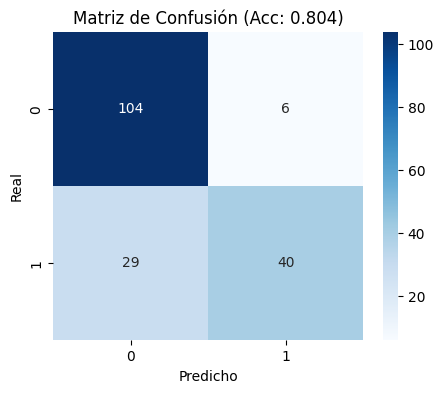

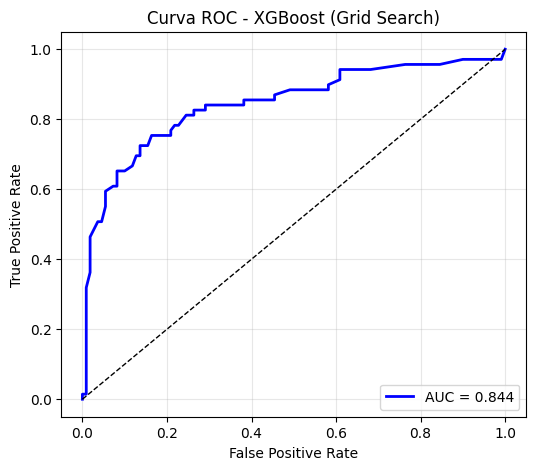

📊 Accuracy final: 0.8045 | AUC: 0.8442

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.95      0.86       110
           1       0.87      0.58      0.70        69

    accuracy                           0.80       179
   macro avg       0.83      0.76      0.78       179
weighted avg       0.82      0.80      0.79       179



In [54]:
# ============================================================
# 🧩 XGBoost con Grid Search (versión limpia y sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Grid Search
# ============================================================

print("🔹 Iniciando Grid Search para XGBoost...\n")

start_time = time.time()

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.25, 0.5]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro: {grid_search.best_params_}")
print(f"✅ Mejor accuracy CV: {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost (Grid Search)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


🔹 Iniciando Optimización Bayesiana para XGBoost...

✅ Mejor parámetro (BayesSearch): OrderedDict([('colsample_bytree', 0.7779330049204607), ('gamma', 0.45936126083468853), ('learning_rate', 0.014285310742471472), ('max_depth', 5), ('n_estimators', 97), ('subsample', 0.7814661375225196)])
✅ Mejor accuracy CV: 0.8260
⏱️ Tiempo total BayesSearch: 29.08 segundos



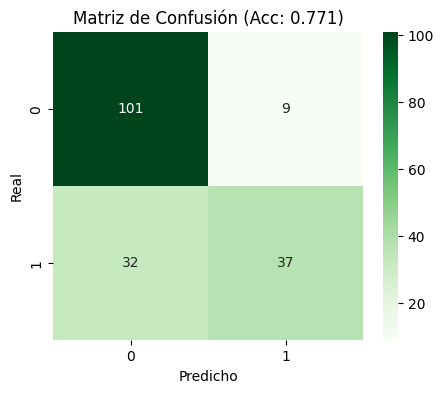

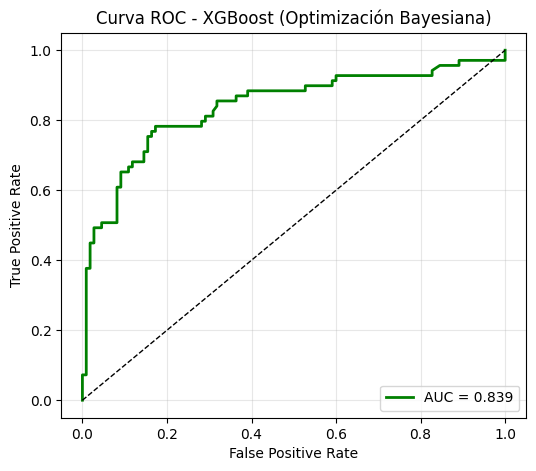

📊 Accuracy final: 0.7709 | AUC: 0.8389

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       110
           1       0.80      0.54      0.64        69

    accuracy                           0.77       179
   macro avg       0.78      0.73      0.74       179
weighted avg       0.78      0.77      0.76       179



In [55]:
# ============================================================
# 🤖 XGBoost con Optimización Bayesiana (versión sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Optimización Bayesiana
# ============================================================

print("🔹 Iniciando Optimización Bayesiana para XGBoost...\n")

start_time = time.time()

search_spaces = {
    'n_estimators': (50, 300),
    'max_depth': (3, 8),
    'learning_rate': (0.01, 0.3, 'log-uniform'),
    'subsample': (0.6, 1.0),
    'colsample_bytree': (0.6, 1.0),
    'gamma': (0.0, 0.5)
}

bayes_search = BayesSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    search_spaces=search_spaces,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
bayes_search.fit(X_train, y_train)
bayes_time = time.time() - start_time

print(f"✅ Mejor parámetro (BayesSearch): {bayes_search.best_params_}")
print(f"✅ Mejor accuracy CV: {bayes_search.best_score_:.4f}")
print(f"⏱️ Tiempo total BayesSearch: {bayes_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - XGBoost (Optimización Bayesiana)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


# Random Forest

🔹 Iniciando Grid Search para Random Forest...

✅ Mejor parámetro: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
✅ Mejor accuracy CV: 0.8316
⏱️ Tiempo total Grid Search: 132.62 segundos



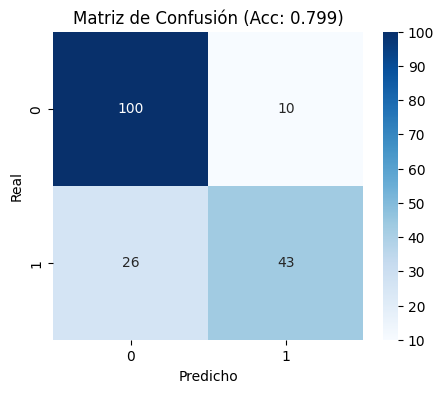

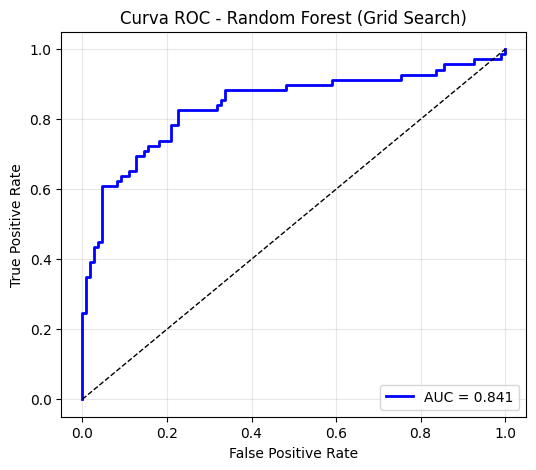

📊 Accuracy final: 0.7989 | AUC: 0.8414

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85       110
           1       0.81      0.62      0.70        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



In [56]:
# ============================================================
# 🌲 Random Forest con Grid Search (versión limpia y sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Grid Search
# ============================================================

print("🔹 Iniciando Grid Search para Random Forest...\n")

start_time = time.time()

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro: {grid_search.best_params_}")
print(f"✅ Mejor accuracy CV: {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest (Grid Search)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


🔹 Iniciando Optimización Bayesiana para Random Forest...

✅ Mejor parámetro (BayesSearch): OrderedDict([('max_depth', 15), ('max_features', 'log2'), ('min_samples_leaf', 1), ('min_samples_split', 10), ('n_estimators', 500)])
✅ Mejor accuracy CV: 0.8302
⏱️ Tiempo total BayesSearch: 53.41 segundos



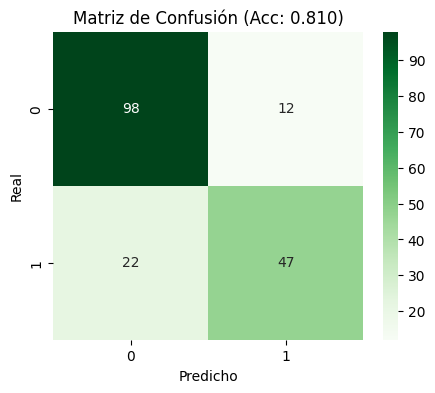

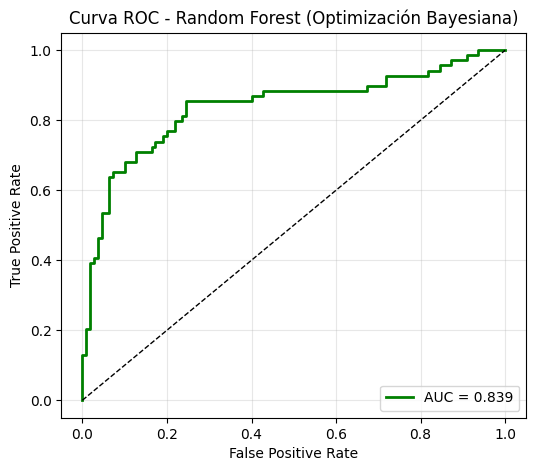

📊 Accuracy final: 0.8101 | AUC: 0.8390

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



In [57]:
# ============================================================
# 🤖 Random Forest con Optimización Bayesiana (versión sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Optimización Bayesiana
# ============================================================

print("🔹 Iniciando Optimización Bayesiana para Random Forest...\n")

start_time = time.time()

search_spaces = {
    'n_estimators': (100, 500),
    'max_depth': (3, 15),
    'min_samples_split': (2, 10),
    'min_samples_leaf': (1, 5),
    'max_features': ['sqrt', 'log2']
}

bayes_search = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    search_spaces=search_spaces,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
bayes_search.fit(X_train, y_train)
bayes_time = time.time() - start_time

print(f"✅ Mejor parámetro (BayesSearch): {bayes_search.best_params_}")
print(f"✅ Mejor accuracy CV: {bayes_search.best_score_:.4f}")
print(f"⏱️ Tiempo total BayesSearch: {bayes_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Random Forest (Optimización Bayesiana)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


# SVM

🔹 Iniciando Grid Search para SVM...

✅ Mejor parámetro: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
✅ Mejor accuracy CV: 0.8259
⏱️ Tiempo total Grid Search: 20.86 segundos



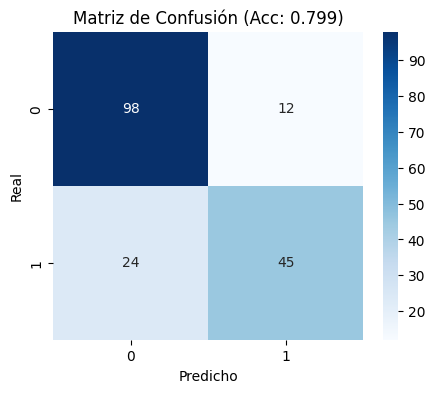

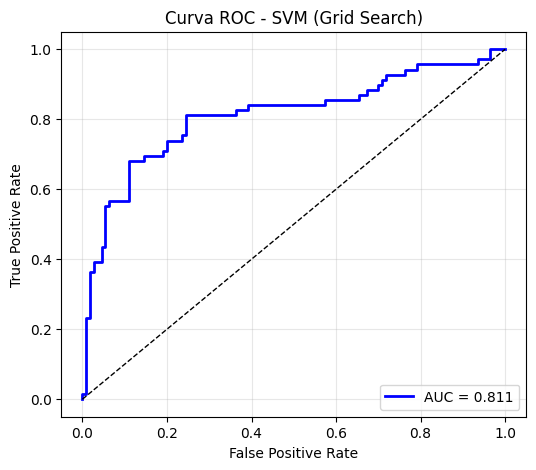

📊 Accuracy final: 0.7989 | AUC: 0.8113

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84       110
           1       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



In [58]:
# ============================================================
# ⚙️ SVM con Grid Search (versión limpia y sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Grid Search
# ============================================================

print("🔹 Iniciando Grid Search para SVM...\n")

start_time = time.time()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

grid_search = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print(f"✅ Mejor parámetro: {grid_search.best_params_}")
print(f"✅ Mejor accuracy CV: {grid_search.best_score_:.4f}")
print(f"⏱️ Tiempo total Grid Search: {grid_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM (Grid Search)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))


🔹 Iniciando Optimización Bayesiana para SVM...

✅ Mejor parámetro (BayesSearch): OrderedDict([('C', 8.986907898467031), ('degree', 2), ('gamma', 0.09921337614843434), ('kernel', 'rbf')])
✅ Mejor accuracy CV: 0.8329
⏱️ Tiempo total BayesSearch: 587.79 segundos



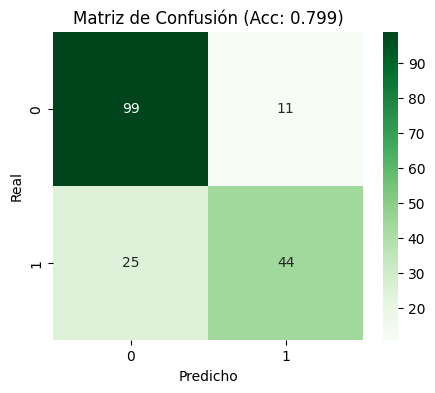

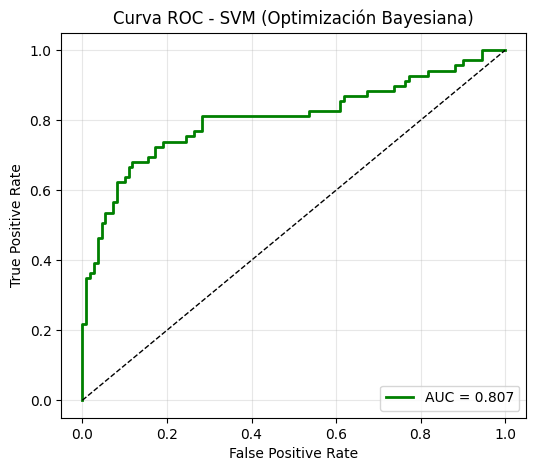

📊 Accuracy final: 0.7989 | AUC: 0.8066

📘 Reporte Clasificación:
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.64      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



In [59]:
# ============================================================
# 🧠 SVM con Optimización Bayesiana (versión sin warnings)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from skopt import BayesSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc
)
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# ============================================================
# 1️⃣ Cargar y preparar dataset Titanic
# ============================================================

train_data = pd.read_csv('/kaggle/input/titanic-machine-learning-from-disaster/train.csv')

train_data = train_data.drop(['Name','Ticket','Cabin','PassengerId'], axis=1)
train_data['Age'] = train_data['Age'].fillna(train_data['Age'].mean())
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

encoder = OrdinalEncoder()
train_data[['Sex','Embarked']] = encoder.fit_transform(train_data[['Sex','Embarked']])

X = train_data.drop('Survived', axis=1)
y = train_data['Survived']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# 2️⃣ Optimización Bayesiana
# ============================================================

print("🔹 Iniciando Optimización Bayesiana para SVM...\n")

start_time = time.time()

search_spaces = {
    'C': (1e-2, 1e3, 'log-uniform'),
    'gamma': (1e-4, 1e-1, 'log-uniform'),
    'degree': (2, 5),
    'kernel': ['linear', 'rbf', 'poly']
}

bayes_search = BayesSearchCV(
    estimator=SVC(probability=True, random_state=42),
    search_spaces=search_spaces,
    n_iter=25,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
bayes_search.fit(X_train, y_train)
bayes_time = time.time() - start_time

print(f"✅ Mejor parámetro (BayesSearch): {bayes_search.best_params_}")
print(f"✅ Mejor accuracy CV: {bayes_search.best_score_:.4f}")
print(f"⏱️ Tiempo total BayesSearch: {bayes_time:.2f} segundos\n")

# ============================================================
# 3️⃣ Evaluación
# ============================================================

best_model = bayes_search.best_estimator_
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

# --- Matriz de Confusión ---
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title(f"Matriz de Confusión (Acc: {acc:.3f})")
plt.xlabel("Predicho"); plt.ylabel("Real")
plt.show()

# --- Curva ROC ---
y_prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - SVM (Optimización Bayesiana)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"📊 Accuracy final: {acc:.4f} | AUC: {roc_auc:.4f}\n")
print("📘 Reporte Clasificación:")
print(classification_report(y_test, y_pred))
